In [ ]:
import pandas as pd # For data manipulation and analysis.
import numpy as np # For numerical operations
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt # Visualizations
import seaborn as sns # A statistical data visualization library based on matplotlib
import statsmodels.api as sm # Library for estimating and testing statistical models

from google.colab import drive # To connect Google Drive to the Colab environments
drive.mount('/content/drive', force_remount=True)

df = pd.read_csv('/content/drive/MyDrive/portfolio/Decoding Health Risk Factors Related to Diabetes/diabetes_012_health_indicators_BRFSS2015.csv')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Cleaning


In [ ]:
df.head(10)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,2.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


In [ ]:
# Boolean indicator columns
df['No Diabetes'] = df['Diabetes_012'] == 0 # no diabetes
df['Pre Diabetes'] = df['Diabetes_012'] == 1 # pre diabetes
df['Diabetes'] = df['Diabetes_012'] == 2 # diabetes

df.head(10)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,No Diabetes,Pre Diabetes,Diabetes
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,18.0,15.0,1.0,0.0,9.0,4.0,3.0,True,False,False
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,7.0,6.0,1.0,True,False,False
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,30.0,30.0,1.0,0.0,9.0,4.0,8.0,True,False,False
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,11.0,3.0,6.0,True,False,False
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,3.0,0.0,0.0,0.0,11.0,5.0,4.0,True,False,False
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,0.0,2.0,0.0,1.0,10.0,6.0,8.0,True,False,False
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,0.0,14.0,0.0,0.0,9.0,6.0,7.0,True,False,False
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,11.0,4.0,4.0,True,False,False
8,2.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,...,30.0,30.0,1.0,0.0,9.0,5.0,1.0,False,False,True
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,8.0,4.0,3.0,True,False,False


In [ ]:
# Replaces Diabetes_012 numbers for diabeters type
df['Diabetes_012'] = df['Diabetes_012'].astype(str) # Makes numbers under Diabetes_012 column strings so they can be replaced
df['Diabetes_012'] = df['Diabetes_012'].str.replace('0.0','No Diabetes')
df['Diabetes_012'] = df['Diabetes_012'].str.replace('1.0','Pre Diabetes')
df['Diabetes_012'] = df['Diabetes_012'].str.replace('2.0','Diabetes')
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,No Diabetes,Pre Diabetes,Diabetes
0,No Diabetes,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,18.0,15.0,1.0,0.0,9.0,4.0,3.0,True,False,False
1,No Diabetes,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,7.0,6.0,1.0,True,False,False
2,No Diabetes,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,30.0,30.0,1.0,0.0,9.0,4.0,8.0,True,False,False
3,No Diabetes,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,11.0,3.0,6.0,True,False,False
4,No Diabetes,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,3.0,0.0,0.0,0.0,11.0,5.0,4.0,True,False,False


In [ ]:
column_counts = df.count()
print(column_counts)
# all columns have the same amount of inputs

Diabetes_012            253680
HighBP                  253680
HighChol                253680
CholCheck               253680
BMI                     253680
Smoker                  253680
Stroke                  253680
HeartDiseaseorAttack    253680
PhysActivity            253680
Fruits                  253680
Veggies                 253680
HvyAlcoholConsump       253680
AnyHealthcare           253680
NoDocbcCost             253680
GenHlth                 253680
MentHlth                253680
PhysHlth                253680
DiffWalk                253680
Sex                     253680
Age                     253680
Education               253680
Income                  253680
No Diabetes             253680
Pre Diabetes            253680
Diabetes                253680
dtype: int64


# Investigating column relationships

Investigating how each column relates to the diabetes outcome.


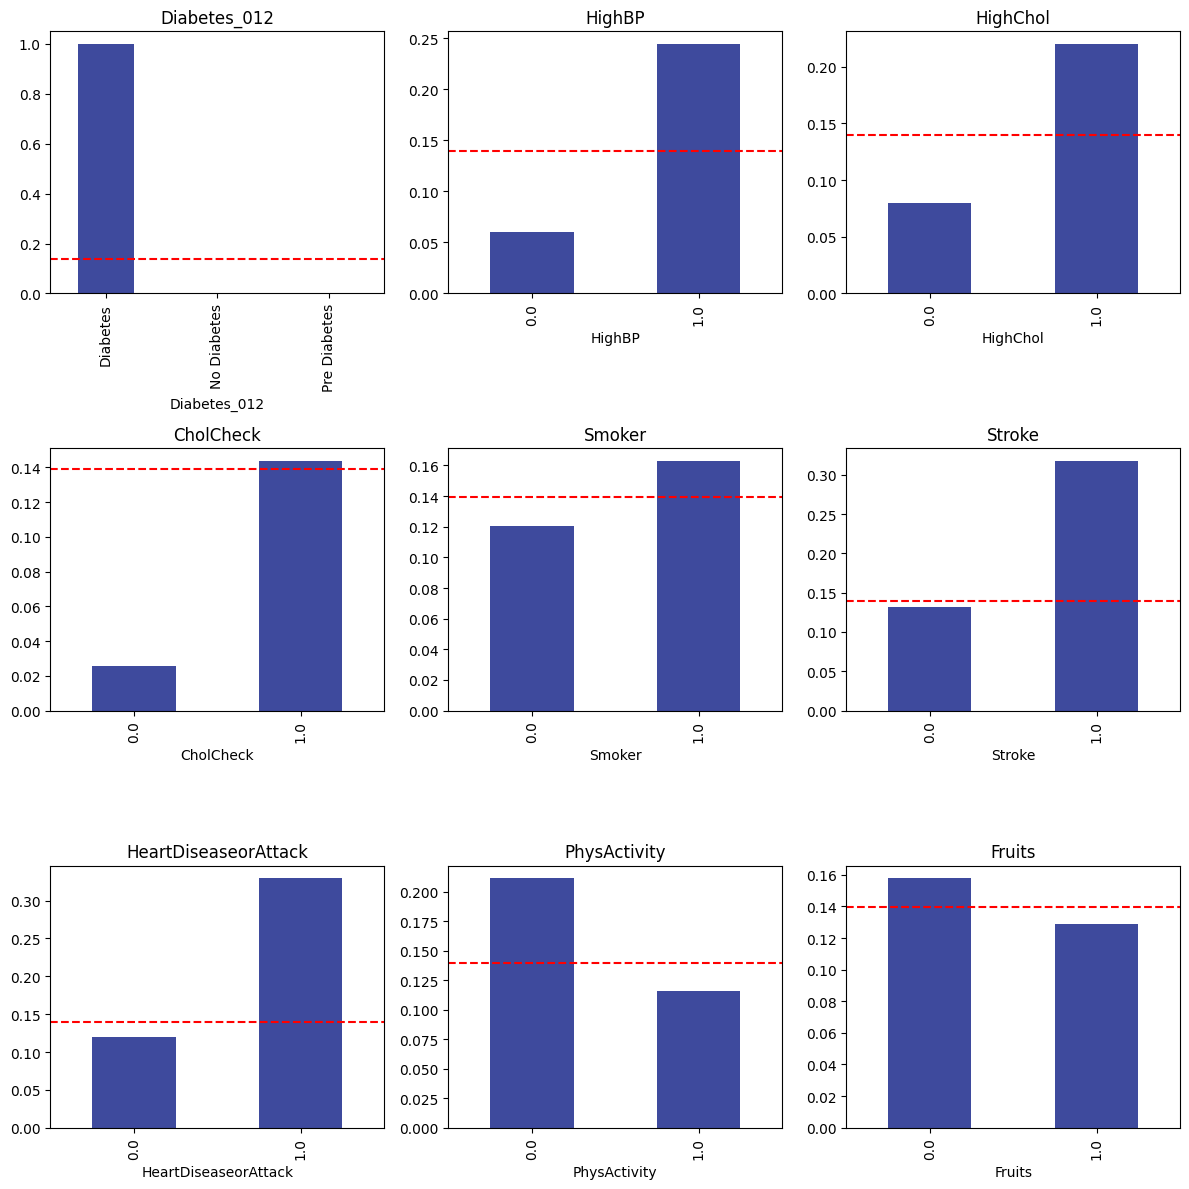

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
axs = axs.flatten()

index = 0
for col in df.columns:
    if col not in ['Pre Diabetes', 'Diabetes', 'No Diabetes', 'BMI', 'MentHlth', 'PhysHlth']:
        ax = axs[index]
        df.groupby(col)['Diabetes'].mean().plot(kind='bar', title=col, ax=ax, color = '#3e4a9d')
        ax.axhline(df['Diabetes'].mean(), color='red', linestyle='dashed')
        index += 1

        if index >= len(axs):
            break

plt.tight_layout()
plt.show()


# Basic logistic regression model

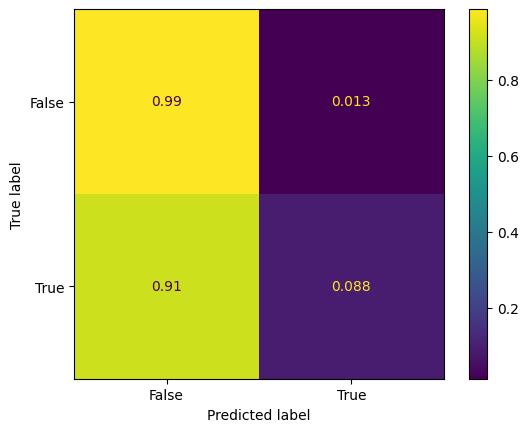

In [ ]:
logr = LogisticRegression(max_iter=10**5)

# random testing
X = df[['HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'Fruits', 'HvyAlcoholConsump', 'Sex', 'Age', 'Income']]
y = df['Diabetes']

logr.fit(X, y)

preds = logr.predict(X)

df['logr_preds'] = preds

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_true=y, y_pred=preds, normalize='true')

# Balance

,HighChol
is_false_positive,
False,0.495516
True,0.713179


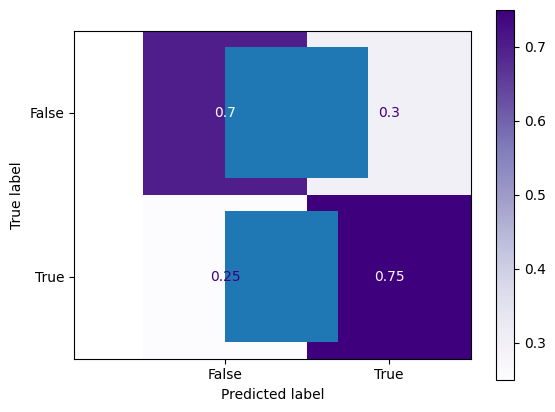

In [ ]:
df['Diabetes'].value_counts()

nondiabetic_df = df[df['Diabetes'] == 0]
diabetic_df = df[df['Diabetes'] == 1]

nondiabetic_sample_df = nondiabetic_df.sample(n=len(diabetic_df))

balanced_df = pd.concat([nondiabetic_sample_df, diabetic_df])

balanced_df['Diabetes'].value_counts()

from sklearn.linear_model import LogisticRegression

logr = LogisticRegression(max_iter=10**5)

X = balanced_df[['HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'Fruits', 'HvyAlcoholConsump', 'Sex', 'Age', 'Income']]
y = balanced_df['Diabetes']

logr.fit(X, y)

preds = logr.predict(X)

balanced_df['logr_preds'] = preds
ConfusionMatrixDisplay.from_predictions(y_true=y, y_pred=preds, normalize='true', cmap='Purples')

# Computing accuracy by hand
np.sum(y == preds) / len(y)

# Computing accuracy using a function
from sklearn.metrics import accuracy_score
accuracy_score(y, preds)

plt.barh(X.columns, logr.coef_[0])

false_positives = (y == False) & (preds == True)
balanced_df['is_false_positive'] = false_positives

balanced_df.head()

# People with high BP are being flagged as diabetic when they are not
balanced_df.groupby('is_false_positive')['HighBP'].mean()

balanced_df.groupby('is_false_positive')['HighChol'].mean()


In [ ]:
"""Imagine that these false positives have both high BP and cholesterol, however they tend to have higher income. Then, we'll make a new column for the model to use which flags this."""

balanced_df.head(1)

balanced_df['High readings high earner'] = (balanced_df['HighBP'] == 1) & (balanced_df['HighChol'] == 1) & (balanced_df['Income'] > 6)

balanced_df.head()

# prompt: Find the average of how many people with No diabetes = true and high bp = 1 and high chol = 1 are in the balanced_df

# Calculate the average of people with No diabetes = True, high bp = 1, and high chol = 1
average_people = balanced_df[(balanced_df['No Diabetes'] == True) & (balanced_df['HighBP'] == 1) & (balanced_df['HighChol'] == 1)].shape[0] / balanced_df.shape[0]
print(f"The average of people with No diabetes = True, high bp = 1, and high chol = 1 is: {average_people}")

# prompt: make a dataframe with just the people who don't have diabetes, but have both High bp and high chol

# Create a mask for people without diabetes, with high blood pressure and high cholesterol
no_diabetes_mask = df['Diabetes_012'] == 'No Diabetes'
high_bp_mask = df['HighBP'] == 1.0
high_chol_mask = df['HighChol'] == 1.0

# Apply the masks to filter the DataFrame
filtered_df = df[no_diabetes_mask & high_bp_mask & high_chol_mask]

# Display the resulting DataFrame
filtered_df

filtered_df.head(5)

filtered_df.drop(columns=['Diabetes_012']).groupby('NoDocbcCost').mean()

balanced_df['Good health reading'] = (balanced_df['HeartDiseaseorAttack'] == 0).astype(int) + (balanced_df['DiffWalk'] == 0).astype(int) + (balanced_df['Stroke'] == False).astype(int)

balanced_df['Bad readings, is drinker'] = (balanced_df['HighBP'] == True) & (balanced_df['HighChol'] == True) & (balanced_df['HvyAlcoholConsump'] == True)

balanced_df['Healthcare'] = (balanced_df['AnyHealthcare'] == 1) & (balanced_df['NoDocbcCost'] == 0)

balanced_df['High readings'] = (balanced_df['HighBP'] == 1) & (balanced_df['HighChol']== 1)

balanced_df.head()

#Smoker 'Fruits', 'Veggies',
X = balanced_df[['HighBP', 'HighChol', 'BMI', 'PhysActivity','Stroke',
                 'AnyHealthcare', 'NoDocbcCost', 'GenHlth','MentHlth', 'PhysHlth', 'DiffWalk',
                 'Sex', 'Age', 'Education', 'Income', 'Good health reading', 'Healthcare',
                 'High readings']]
y = balanced_df['Diabetes']

logr.fit(X, y)

preds = logr.predict(X)

balanced_df['logr_preds'] = preds

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_true=y, y_pred=preds, normalize='true', cmap = 'Purples')

accuracy_score(y, preds)

plt.barh(X.columns, logr.coef_[0], color = '#df3635')

y.unique()

diabetic_prob_preds = logr.predict_proba(X)[:, 1]

balanced_df['logr_preds_proba'] = diabetic_prob_preds

balanced_df.head()

balanced_df['logr_preds_proba_color'] = None
balanced_df.loc[balanced_df['Diabetes'] == True, 'logr_preds_proba_color'] = 'red'
balanced_df.loc[balanced_df['Diabetes'] == False, 'logr_preds_proba_color'] = 'blue'

plt.hist(balanced_df[balanced_df['Diabetes'] == True]['logr_preds_proba'], color='blue', label='Actual true', alpha=0.5)
plt.hist(balanced_df[balanced_df['Diabetes'] == False]['logr_preds_proba'], color='red', label='Actual false', alpha=0.5)
plt.axvline(0.5, color='red', linestyle='dashed')
plt.legend()

balanced_df['is_false_positive'] = (balanced_df['logr_preds'] != balanced_df['Diabetes']) & (balanced_df['Diabetes'] == False)

balanced_df.head()

# Stack together false positives (no diabetes, but prediction of diabetes) with people with diabetes
diabetic_balanced_df = balanced_df[balanced_df['Diabetes'] == True]
diabetic_balanced_df['diabetic_indic'] = True
false_positives_df = balanced_df[balanced_df['is_false_positive'] == True]
false_positives_df['diabetic_indic'] = False

# Stack both together
diabetic_fp_stacked_df = pd.concat([diabetic_balanced_df, false_positives_df])

import numpy as np

for col in diabetic_fp_stacked_df.select_dtypes(np.number).columns:
  if diabetic_fp_stacked_df[col].nunique() < 10:
    diabetic_fp_stacked_df.groupby('diabetic_indic')[col].mean().plot(kind='barh', title=col)
    plt.show()

plt.hist(balanced_df[balanced_df['Diabetes'] == True]['logr_preds_proba'], color='blue', label='Actual true', alpha=0.5)
plt.hist(balanced_df[balanced_df['Diabetes'] == False]['logr_preds_proba'], color='red', label='Actual false', alpha=0.5)
plt.axvline(0.5, color='red', linestyle='dashed')
plt.legend()